In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import seaborn as sns
import os

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [36]:
print(os.listdir())

['.config', 'trum_tweet_sentiment_analysis (1).csv', 'sample_data']


In [37]:
df = pd.read_csv('trum_tweet_sentiment_analysis (1).csv', on_bad_lines='skip', engine='python')
print(df.shape)
print(df.head())
print(df['Sentiment'].value_counts())

(1850123, 2)
                                                text  Sentiment
0  RT @JohnLeguizamo: #trump not draining swamp b...          0
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0
2  Trump protests: LGBTQ rally in New York https:...          1
3  "Hi I'm Piers Morgan. David Beckham is awful b...          0
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...          0
Sentiment
0    1244211
1     605912
Name: count, dtype: int64


In [38]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r"don't", 'do not', text)
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"won't", 'will not', text)
    text = re.sub(r"n't", ' not', text)
    text = re.sub(r"'re", ' are', text)
    text = re.sub(r"'s", ' is', text)
    text = re.sub(r"'d", ' would', text)
    text = re.sub(r"'ll", ' will', text)
    text = re.sub(r"'ve", ' have', text)
    text = re.sub(r"'m", ' am', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
print(df[['text', 'Sentiment', 'cleaned_text']].head())

                                                text  Sentiment  \
0  RT @JohnLeguizamo: #trump not draining swamp b...          0   
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0   
2  Trump protests: LGBTQ rally in New York https:...          1   
3  "Hi I'm Piers Morgan. David Beckham is awful b...          0   
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...          0   

                                        cleaned_text  
0  rt trump draining swamp taxpayer dollar trip a...  
1  icymi hacker rig fm radio station play antitru...  
2    trump protest lgbtq rally new york bbcworld via  
3  hi pier morgan david beckham awful donald trum...  
4  rt tech firm suing buzzfeed publishing unverif...  


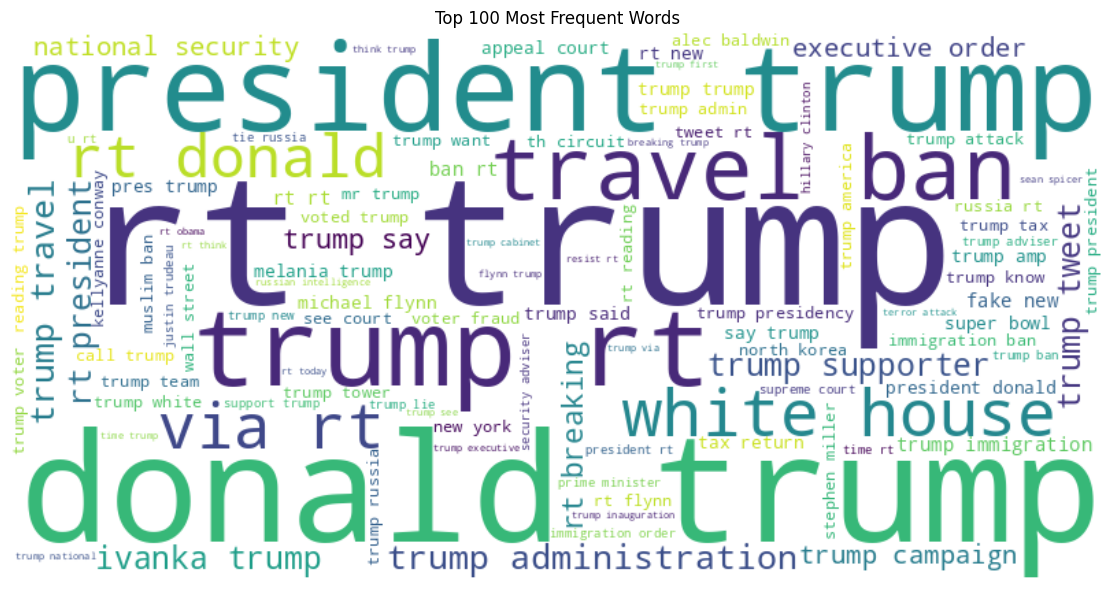

In [39]:
all_words = ' '.join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.tight_layout()
plt.show()

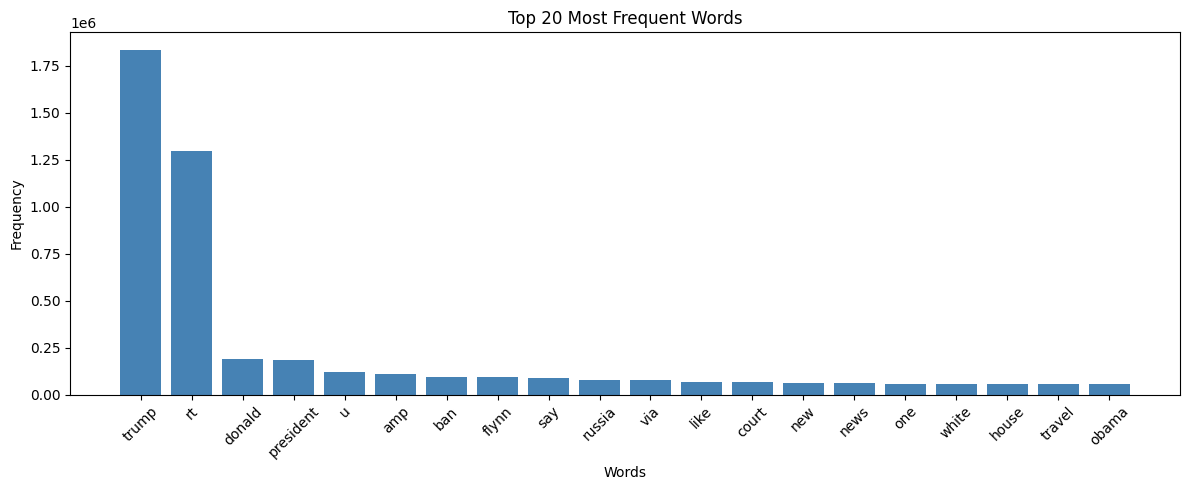

In [40]:
from collections import Counter

word_freq = Counter(' '.join(df['cleaned_text']).split())
common_words = word_freq.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['Sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['sentiment_encoded'],
    test_size=0.2,
    random_state=42
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Train size: 1480098, Test size: 370025


In [42]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))
print(f'95th percentile sequence length (max_len): {max_len}')

95th percentile sequence length (max_len): 16


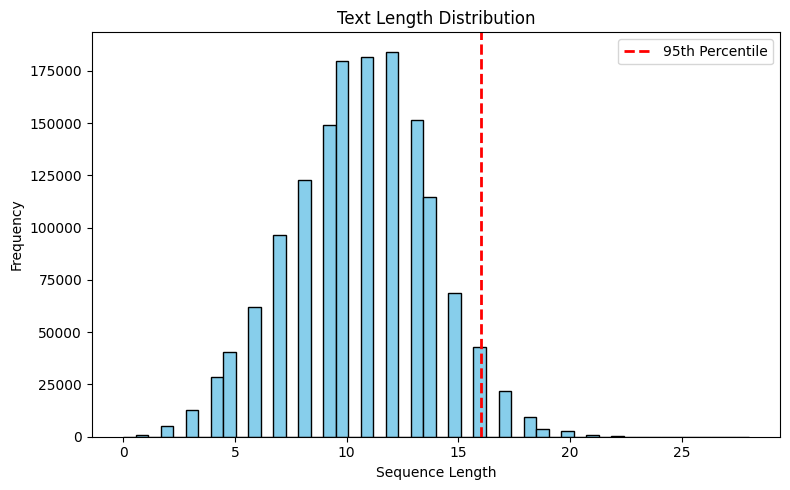

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape: {X_test_pad.shape}')

X_train_pad shape: (1480098, 16)
X_test_pad shape: (370025, 16)


In [45]:
vocab_size = 10000
embedding_dim = 128
rnn_units = 64

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(rnn_units),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(rnn_units),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
rnn_checkpoint = ModelCheckpoint('best_rnn_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[rnn_checkpoint, early_stop]
)

Epoch 1/10
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9193 - loss: 0.2028
Epoch 1: val_accuracy improved from None to 0.95819, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 121s 5ms/step - accuracy: 0.9426 - loss: 0.1543 - val_accuracy: 0.9582 - val_loss: 0.1188
Epoch 2/10
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9650 - loss: 0.1022
Epoch 2: val_accuracy improved from 0.95819 to 0.96282, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 111s 5ms/step - accuracy: 0.9647 - loss: 0.1033 - val_accuracy: 0.9628 - val_loss: 0.1081
Epoch 3/10
23119/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9707 - loss: 0.0868
Epoch 3: val_accuracy improved from 0.96282 to 0.96428, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9697 - loss: 0.0897 - val_accuracy: 0.9643 - val_loss: 0.1042
Epoch 4/10
23124/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9736 - loss: 0.0790
Epoch 4: val_accuracy did not improve from 0.96428
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 112s 5ms/step - accuracy: 0.9723 - loss: 0.0826 - val_accuracy: 0.9640 - val_loss: 0.1106
Epoch 5/10
23115/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9752 - loss: 0.0744
Epoch 5: val_accuracy did not improve from 0.96428
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9736 - loss: 0.0788 - val_accuracy: 0.9610 - val_loss: 0.1125
Epoch 6/10
23125/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - loss: 0.0726
Epoch 6: val_accuracy did not improve from 0.96428
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9744 - loss: 0.0764 - val_accuracy: 0.9631 - val_loss: 0.1087
Epoch 6: early stopping
Restorin

In [48]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
lstm_checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[lstm_checkpoint, early_stop_lstm]
)

Epoch 1/10
23120/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9243 - loss: 0.1888
Epoch 1: val_accuracy improved from None to 0.96408, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 193s 8ms/step - accuracy: 0.9479 - loss: 0.1397 - val_accuracy: 0.9641 - val_loss: 0.1025
Epoch 2/10
23125/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.0877
Epoch 2: val_accuracy improved from 0.96408 to 0.97002, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 166s 7ms/step - accuracy: 0.9701 - loss: 0.0862 - val_accuracy: 0.9700 - val_loss: 0.0875
Epoch 3/10
23125/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9770 - loss: 0.0670
Epoch 3: val_accuracy improved from 0.97002 to 0.97211, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 165s 7ms/step - accuracy: 0.9766 - loss: 0.0682 - val_accuracy: 0.9721 - val_loss: 0.0822
Epoch 4/10
23126/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9816 - loss: 0.0541
Epoch 4: val_accuracy improved from 0.97211 to 0.97273, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 165s 7ms/step - accuracy: 0.9808 - loss: 0.0560 - val_accuracy: 0.9727 - val_loss: 0.0822
Epoch 5/10
23120/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9848 - loss: 0.0440
Epoch 5: val_accuracy improved from 0.97273 to 0.97288, saving model to best_lstm_model.h5



Epoch 5: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 203s 7ms/step - accuracy: 0.9839 - loss: 0.0468 - val_accuracy: 0.9729 - val_loss: 0.0833
Epoch 6/10
23122/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9874 - loss: 0.0368
Epoch 6: val_accuracy improved from 0.97288 to 0.97306, saving model to best_lstm_model.h5



Epoch 6: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 165s 7ms/step - accuracy: 0.9866 - loss: 0.0394 - val_accuracy: 0.9731 - val_loss: 0.0896
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


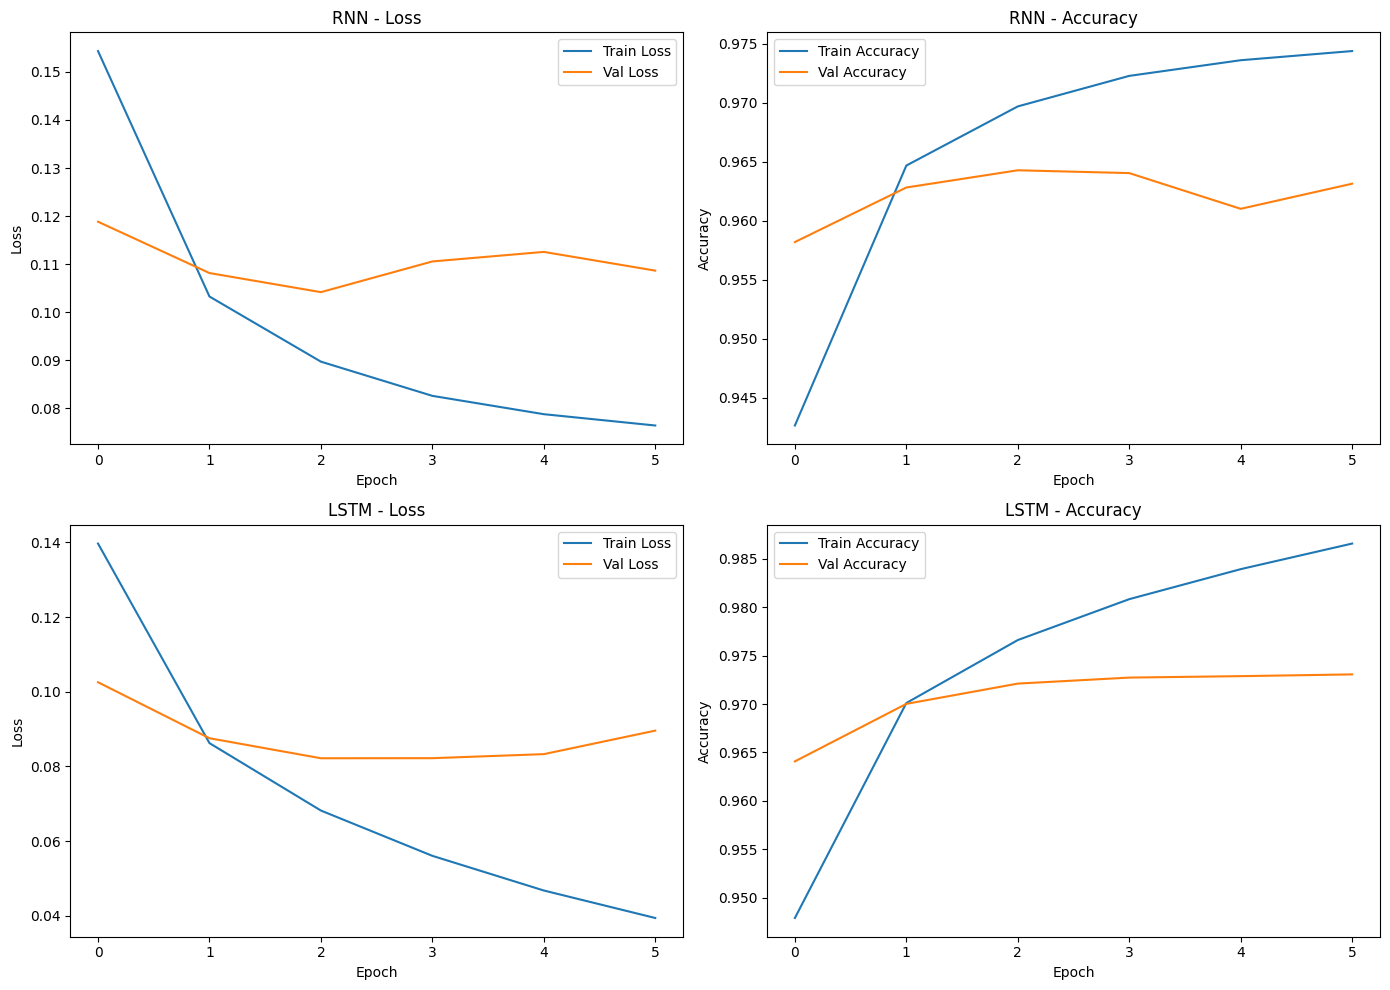

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(rnn_history.history['loss'], label='Train Loss')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('RNN - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(rnn_history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(rnn_history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('RNN - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(lstm_history.history['loss'], label='Train Loss')
axes[1, 0].plot(lstm_history.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('LSTM - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

axes[1, 1].plot(lstm_history.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('LSTM - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [52]:
rnn_pred_probs = rnn_model.predict(X_test_pad)
rnn_pred = (rnn_pred_probs > 0.5).astype(int).flatten()

lstm_pred_probs = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred_probs > 0.5).astype(int).flatten()


class_names = le.classes_.astype(str)

print('=== RNN Results ===')
print(f'Accuracy: {accuracy_score(y_test, rnn_pred):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, rnn_pred))
print('Classification Report:')
print(classification_report(y_test, rnn_pred, target_names=class_names))

print('\n=== LSTM Results ===')
print(f'Accuracy: {accuracy_score(y_test, lstm_pred):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, lstm_pred))
print('Classification Report:')
print(classification_report(y_test, lstm_pred, target_names=class_names))

11564/11564 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step
=== RNN Results ===
Accuracy: 0.9643
Confusion Matrix:
[[242540   6023]
 [  7194 114268]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    248563
           1       0.95      0.94      0.95    121462

    accuracy                           0.96    370025
   macro avg       0.96      0.96      0.96    370025
weighted avg       0.96      0.96      0.96    370025


=== LSTM Results ===
Accuracy: 0.9721
Confusion Matrix:
[[243839   4724]
 [  5595 115867]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    248563
           1       0.96      0.95      0.96    121462

    accuracy                           0.97    370025
   macro avg       0.97      0.97      0.97    370025
weighted avg       0.97      0.97      0.97    370025



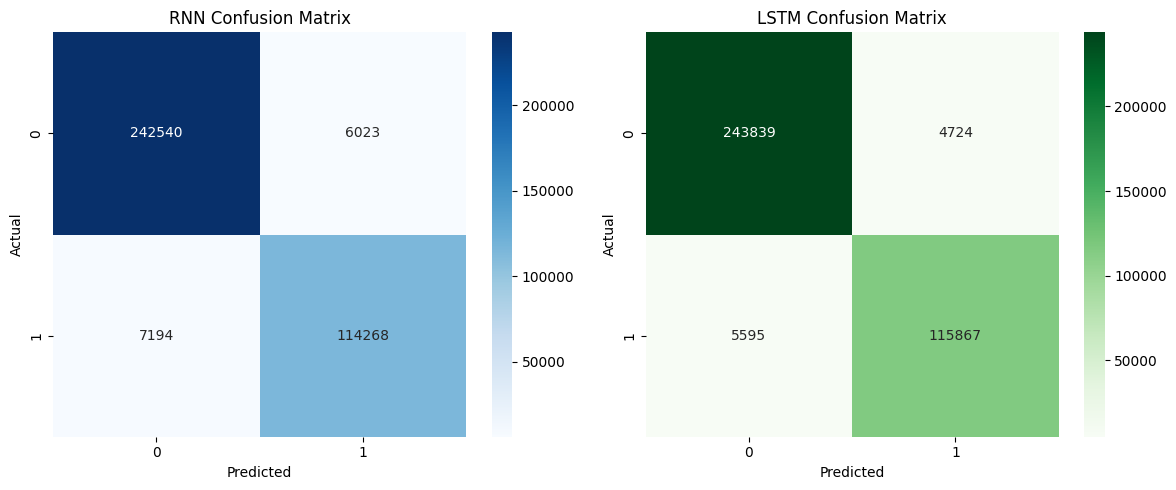

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, rnn_pred), annot=True, fmt='d', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
axes[0].set_title('RNN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, lstm_pred), annot=True, fmt='d', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

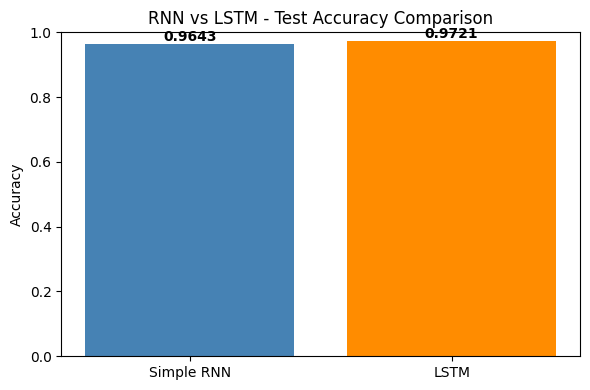

In [54]:
rnn_acc = accuracy_score(y_test, rnn_pred)
lstm_acc = accuracy_score(y_test, lstm_pred)

plt.figure(figsize=(6, 4))
plt.bar(['Simple RNN', 'LSTM'], [rnn_acc, lstm_acc], color=['steelblue', 'darkorange'])
plt.title('RNN vs LSTM - Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate([rnn_acc, lstm_acc]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
def predict_sentiment(text, model, tokenizer, max_len, le):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = le.classes_[int(prob > 0.5)]
    return label, prob

test_tweets = [
    "I absolutely love this product, it's amazing!",
    "This is the worst experience I've ever had.",
    "It was okay, nothing special."
]

print('LSTM Predictions:')
for tweet in test_tweets:
    label, prob = predict_sentiment(tweet, lstm_model, tokenizer, max_len, le)
    print(f'  Tweet: "{tweet}"')
    print(f'  Sentiment: {label} (confidence: {prob:.4f})\n')

LSTM Predictions:
  Tweet: "I absolutely love this product, it's amazing!"
  Sentiment: 1 (confidence: 0.9978)

  Tweet: "This is the worst experience I've ever had."
  Sentiment: 0 (confidence: 0.0016)

  Tweet: "It was okay, nothing special."
  Sentiment: 1 (confidence: 0.9785)

